In [7]:
# Importing libraries Required for Forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor

In [8]:
# Loading cleaned sales data
sales = pd.read_csv("../data/processed/sales_cleaned.csv")

# Converting Date column into datetime format
sales["Date"] = pd.to_datetime(sales["Date"])

# Checking the loaded data
print("Sales shape:", sales.shape)
sales.head()

Sales shape: (36550, 6)


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [9]:
# Creating weekly demand for each SKU
weekly_sales = (sales.groupby(["SKU",pd.Grouper(key="Date", freq="W-SUN")])
                ["Units_Sold"].sum().reset_index())

# Renaming columns for easier use
weekly_sales = weekly_sales.rename(columns={"Date": "Week","Units_Sold": "Weekly_Demand"})

# Removing the incomplete final week from the weekly data
last_complete_week = sales["Date"].max() - pd.Timedelta(days=(sales["Date"].max().weekday() + 1))
weekly_sales = weekly_sales[weekly_sales["Week"] <= last_complete_week].copy()

In [10]:
# Checking number of SKUs and weeks available
print("Number of SKUs:", weekly_sales["SKU"].nunique())
print("Number of weeks:", weekly_sales["Week"].nunique())
print("Weekly data shape:", weekly_sales.shape)
print("Last week:", weekly_sales["Week"].max())

Number of SKUs: 50
Number of weeks: 104
Weekly data shape: (5200, 3)
Last week: 2025-12-28 00:00:00


In [11]:
# Creating a complete weekly timeline for every SKU
all_skus = weekly_sales["SKU"].unique()

all_weeks = pd.date_range(weekly_sales["Week"].min(),
    weekly_sales["Week"].max(),freq="W-SUN")

# Creating every possible SKU and week combination
complete_index = pd.MultiIndex.from_product([all_skus, all_weeks],names=["SKU", "Week"])

# Filling missing SKU-week Combinations with zero demand
weekly_sales = (weekly_sales.set_index(["SKU", "Week"]).reindex(complete_index, fill_value=0).reset_index())

print("Complete weekly data shape:", weekly_sales.shape)
print("Missing values:", weekly_sales.isnull().sum().sum())

Complete weekly data shape: (5200, 3)
Missing values: 0


In [12]:
# Sorting data by SKU and week
weekly_sales = weekly_sales.sort_values(["SKU", "Week"]).reset_index(drop=True)

weekly_sales.head()

,SKU,Week,Weekly_Demand
0,SKU001,2024-01-07,106
1,SKU001,2024-01-14,85
2,SKU001,2024-01-21,117
3,SKU001,2024-01-28,89
4,SKU001,2024-02-04,119


In [13]:
# Creating a seasonal naive forecast using demand from 52 weeks earlier
weekly_sales["Seasonal_Naive"] = (weekly_sales.groupby("SKU")["Weekly_Demand"].shift(52))

# Checking the seasonal naive values
weekly_sales[["SKU", "Week", "Weekly_Demand", "Seasonal_Naive"]].head(60)

,SKU,Week,Weekly_Demand,Seasonal_Naive
0,SKU001,2024-01-07,106,NaN
1,SKU001,2024-01-14,85,NaN
2,SKU001,2024-01-21,117,NaN
3,SKU001,2024-01-28,89,NaN
4,SKU001,2024-02-04,119,NaN
5,SKU001,2024-02-11,112,NaN
6,SKU001,2024-02-18,104,NaN
7,SKU001,2024-02-25,120,NaN
8,SKU001,2024-03-03,103,NaN
9,SKU001,2024-03-10,119,NaN


In [14]:
# Creating previous-week and historical demand features
for lag in [1, 2, 4, 8, 13, 26, 52]:
    weekly_sales[f"Lag_{lag}"] = (weekly_sales.groupby("SKU")["Weekly_Demand"].shift(lag))

In [15]:
# Creating rolling average demand features

weekly_sales["Rolling_Mean_4"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                  .transform(lambda x: x.shift(1).rolling(4).mean()))

weekly_sales["Rolling_Mean_8"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                  .transform(lambda x: x.shift(1).rolling(8).mean()))

weekly_sales["Rolling_Mean_13"] = (weekly_sales.groupby("SKU")["Weekly_Demand"]
                                   .transform(lambda x: x.shift(1).rolling(13).mean()))

In [16]:
# Creating calendar features from the week date
weekly_sales["Year"] = weekly_sales["Week"].dt.year
weekly_sales["Month"] = weekly_sales["Week"].dt.month
weekly_sales["Quarter"] = weekly_sales["Week"].dt.quarter

weekly_sales["Week_Number"] = (weekly_sales["Week"].dt.isocalendar().week.astype(int))

In [17]:
# Removing rows where forecasting features are not available
forecast_data = weekly_sales.dropna().copy()

print("Forecast data shape:", forecast_data.shape)
print("Missing values:", forecast_data.isnull().sum().sum())

Forecast data shape: (2600, 18)
Missing values: 0


In [18]:
# Creating a time-based train and test split
last_week = forecast_data["Week"].max()

test_start = last_week - pd.Timedelta(weeks=7)
train_data = forecast_data[forecast_data["Week"] < test_start].copy()
test_data = forecast_data[forecast_data["Week"] >= test_start].copy()

print("Train period:",train_data["Week"].min(),"to",train_data["Week"].max())
print("Test period:",test_data["Week"].min(),"to",test_data["Week"].max())

Train period: 2025-01-05 00:00:00 to 2025-11-02 00:00:00
Test period: 2025-11-09 00:00:00 to 2025-12-28 00:00:00


In [19]:
# Selecting features that will be used by the forecasting model
features = ["Lag_1","Lag_2","Lag_4","Lag_8","Lag_13","Lag_26","Lag_52",
            "Rolling_Mean_4","Rolling_Mean_8","Rolling_Mean_13","Year","Month","Quarter","Week_Number"]

# Defining the value that the model needs to predict
target = "Weekly_Demand"

In [20]:
# Creating the gradient boosting forecasting model
model = HistGradientBoostingRegressor(max_iter=300,learning_rate=0.05,
                                      max_leaf_nodes=31,l2_regularization=1.0,random_state=42)

# Training the model using historical demand
model.fit(train_data[features],train_data[target])
print("Forecasting model trained successfully")

Forecasting model trained successfully


In [21]:
# Generating predictions for the test period
test_data["Forecast"] = model.predict(test_data[features])

# Making sure forecasted demand cannot be negative
test_data["Forecast"] = test_data["Forecast"].clip(lower=0)
test_data[["SKU", "Week", "Weekly_Demand", "Forecast"]].head()

,SKU,Week,Weekly_Demand,Forecast
96,SKU001,2025-11-09,92,96.882519
97,SKU001,2025-11-16,87,92.881034
98,SKU001,2025-11-23,84,95.783656
99,SKU001,2025-11-30,84,94.751856
100,SKU001,2025-12-07,88,94.448732


In [22]:
# Creating a function to calculate WAPE
def calculate_wape(actual, predicted):
    denominator = np.abs(actual).sum()
    if denominator == 0:
        return np.nan
    return (np.abs(actual - predicted).sum()/ denominator* 100)

In [23]:
# Calculating WAPE for the forecasting model
model_wape = calculate_wape(test_data["Weekly_Demand"],test_data["Forecast"])

print("Model WAPE:", round(model_wape, 2), "%")

Model WAPE: 9.33 %


In [24]:
# Removing rows where the seasonal naive forecast is unavailable
baseline_data = test_data.dropna(subset=["Seasonal_Naive"]).copy()

# Calculating WAPE for the seasonal naive baseline
baseline_wape = calculate_wape(baseline_data["Weekly_Demand"],baseline_data["Seasonal_Naive"])

print("Seasonal Naive WAPE:",round(baseline_wape, 2),"%")

Seasonal Naive WAPE: 11.87 %


In [25]:
# Calculating bias for the forecasting model
model_bias = (test_data["Forecast"] - test_data["Weekly_Demand"]
              ).sum() / test_data["Weekly_Demand"].sum() * 100

# Calculating bias for the seasonal naive baseline
baseline_bias = (baseline_data["Seasonal_Naive"]- baseline_data["Weekly_Demand"]
                 ).sum() / baseline_data["Weekly_Demand"].sum() * 100

print("Model Bias:", round(model_bias, 2), "%")
print("Baseline Bias:", round(baseline_bias, 2), "%")

Model Bias: 0.3 %
Baseline Bias: 0.23 %


In [26]:
# Comparing the forecasting model with the seasonal naive baseline
comparison = pd.DataFrame({"Metric": ["WAPE","Bias"],
    "Seasonal_Naive": [baseline_wape,baseline_bias],
    "Gradient_Boosting": [model_wape,model_bias]})
comparison

,Metric,Seasonal_Naive,Gradient_Boosting
0,WAPE,11.871670,9.334063
1,Bias,0.231642,0.304721


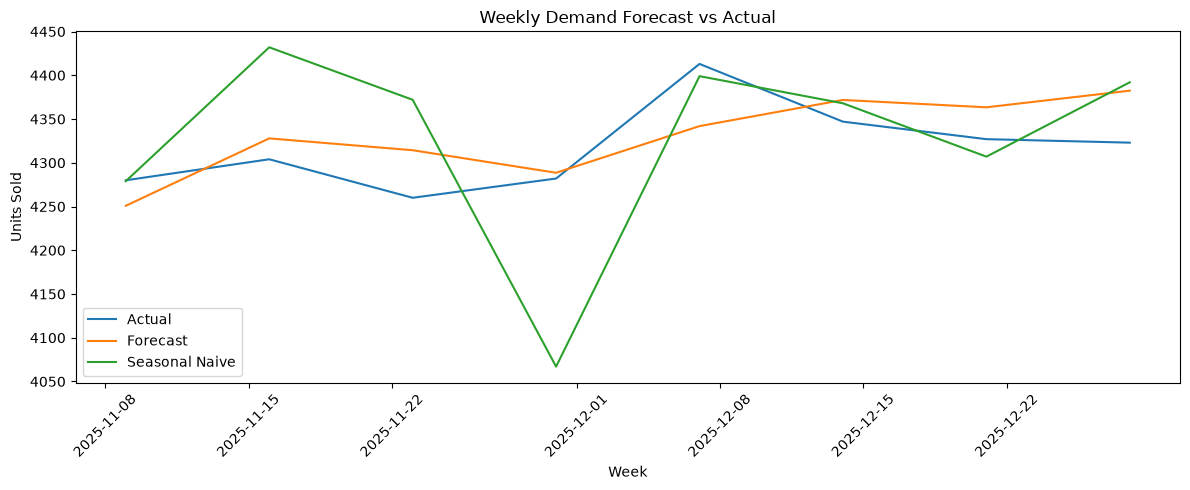

In [27]:
# Comparing actual demand with model and baseline forecasts
plot_data = (test_data.groupby("Week")[["Weekly_Demand","Forecast","Seasonal_Naive"]].sum())

plt.figure(figsize=(12, 5))

plt.plot(plot_data.index,plot_data["Weekly_Demand"],label="Actual")

plt.plot(plot_data.index,plot_data["Forecast"],label="Forecast")

plt.plot(plot_data.index,plot_data["Seasonal_Naive"],label="Seasonal Naive")

plt.title("Weekly Demand Forecast vs Actual")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Calculating forecasting accuracy separately for each SKU
sku_wape = (test_data.groupby("SKU").apply(lambda x: calculate_wape(x["Weekly_Demand"],x["Forecast"]),
                include_groups=False).reset_index(name="WAPE"))

sku_wape.head()

,SKU,WAPE
0,SKU001,10.085867
1,SKU002,18.376989
2,SKU003,15.955959
3,SKU004,11.685538
4,SKU005,5.756194


In [29]:
# Checking SKUs with the lowest forecasting error
sku_wape.sort_values("WAPE").head(10)

,SKU,WAPE
17,SKU018,4.294237
18,SKU019,5.091256
34,SKU035,5.504164
22,SKU023,5.707442
13,SKU014,5.721265
4,SKU005,5.756194
25,SKU026,6.149184
11,SKU012,6.320593
9,SKU010,6.785716
7,SKU008,7.131795


In [30]:
# Checking SKUs with the highest forecasting error
sku_wape.sort_values("WAPE",ascending=False).head(10)

,SKU,WAPE
24,SKU025,27.089329
14,SKU015,22.357141
38,SKU039,21.029264
10,SKU011,18.661288
27,SKU028,18.384577
1,SKU002,18.376989
47,SKU048,16.670795
21,SKU022,16.083592
2,SKU003,15.955959
49,SKU050,15.322264


In [31]:
# Creating the next 8 weeks for future demand forecasting
future_weeks = pd.date_range(weekly_sales["Week"].max() + pd.Timedelta(weeks=1),
                    periods=8,freq="W-SUN")

print(future_weeks)

DatetimeIndex(['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25',
               '2026-02-01', '2026-02-08', '2026-02-15', '2026-02-22'],
              dtype='datetime64[us]', freq='W-SUN')


In [32]:
# Creating future records for every SKU
future_index = pd.MultiIndex.from_product([all_skus, future_weeks],names=["SKU", "Week"])

future_data = pd.DataFrame(index=future_index).reset_index()

future_data["Weekly_Demand"] = np.nan

In [33]:
# Combining historical demand with future forecast periods
forecast_history = weekly_sales[["SKU", "Week", "Weekly_Demand"]].copy()
forecast_full = pd.concat([forecast_history,future_data],ignore_index=True)
forecast_full = forecast_full.sort_values(["SKU", "Week"]).reset_index(drop=True)

In [ ]:
# Generating future forecasts one week at a time
future_predictions = []

for week in future_weeks:
    # Creating lag features using the latest available demand
    for lag in [1, 2, 4, 8, 13, 26, 52]:
        forecast_full[f"Lag_{lag}"]= (forecast_full.groupby("SKU")["Weekly_Demand"].shift(lag))

    # Creating rolling demand features
    forecast_full["Rolling_Mean_4"]=(forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(4).mean()))
    forecast_full["Rolling_Mean_8"]= (forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(8).mean()))
    forecast_full["Rolling_Mean_13"]= (forecast_full.groupby("SKU")["Weekly_Demand"].transform(lambda x: x.shift(1).rolling(13).mean()))

    # Creating calendar features
    forecast_full["Year"] =forecast_full["Week"].dt.year
    forecast_full["Month"] =forecast_full["Week"].dt.month
    forecast_full["Quarter"] =forecast_full["Week"].dt.quarter
    forecast_full["Week_Number"] =(forecast_full["Week"].dt.isocalendar().week.astype(int))

    # Selecting the current future week
    current_rows = forecast_full[forecast_full["Week"] == week].copy()

    # Generating predictions for the current week
    current_rows["Forecast"] = model.predict(current_rows[features])

    # Making sure forecast cannot be negative
    current_rows["Forecast"] = (current_rows["Forecast"].clip(lower=0))

    # Adding predictions back for the next week's features
    for _, row in current_rows.iterrows():
        mask = ((forecast_full["SKU"] == row["SKU"]) &(forecast_full["Week"] == week))

        forecast_full.loc[mask, "Weekly_Demand"] = row["Forecast"]

    # Saving current week predictions
    future_predictions.append(current_rows)

In [35]:
# Combining all future week predictions
future_forecast = pd.concat(future_predictions,ignore_index=True)

# Keeping only the important forecast columns
future_forecast = future_forecast[["SKU","Week","Forecast"]]
future_forecast.head(20)

,SKU,Week,Forecast
0,SKU001,2026-01-04,95.239016
1,SKU002,2026-01-04,63.229514
2,SKU003,2026-01-04,37.581253
3,SKU004,2026-01-04,34.366429
4,SKU005,2026-01-04,112.160785
5,SKU006,2026-01-04,42.669263
6,SKU007,2026-01-04,169.157808
7,SKU008,2026-01-04,104.428665
8,SKU009,2026-01-04,76.398384
9,SKU010,2026-01-04,114.352961


In [36]:
# Checking the final forecast size
print("Forecast rows:", len(future_forecast))
print("SKUs:", future_forecast["SKU"].nunique())
print("Weeks:", future_forecast["Week"].nunique())

Forecast rows: 400
SKUs: 50
Weeks: 8


In [38]:
# Saving the 8-week SKU forecast for later risk analysis
future_forecast.to_csv("../data/processed/sku_8_week_forecast.csv",index=False)
print("8-week forecast saved successfully")

8-week forecast saved successfully


In [39]:
# Creating rolling validation periods
validation_results = []

for i in range(4):
    test_start = forecast_data["Week"].max() - pd.Timedelta(weeks=7 + i * 8)
    test_end = test_start + pd.Timedelta(weeks=7)

    train_cv = forecast_data[forecast_data["Week"] < test_start]

    test_cv = forecast_data[(forecast_data["Week"] >= test_start) &(forecast_data["Week"] <= test_end)]

    validation_results.append({"Fold": i + 1,"Test_Start": test_start,"Test_End": test_end,"Rows": len(test_cv)})

cv_periods = pd.DataFrame(validation_results)

cv_periods

,Fold,Test_Start,Test_End,Rows
0,1,2025-11-09,2025-12-28,400
1,2,2025-09-14,2025-11-02,400
2,3,2025-07-20,2025-09-07,400
3,4,2025-05-25,2025-07-13,400


In [40]:
# Evaluating the model across each validation period
cv_scores = []

for _, period in cv_periods.iterrows():

    test_start = period["Test_Start"]
    test_end = period["Test_End"]

    train_cv = forecast_data[forecast_data["Week"] < test_start]
    test_cv = forecast_data[(forecast_data["Week"] >= test_start) &(forecast_data["Week"] <= test_end)].copy()

    cv_model = HistGradientBoostingRegressor(max_iter=300,learning_rate=0.05,max_leaf_nodes=31,l2_regularization=1.0,random_state=42)
    cv_model.fit(train_cv[features],train_cv[target])

    test_cv["Forecast"] = cv_model.predict(test_cv[features])
    test_cv["Forecast"] = test_cv["Forecast"].clip(lower=0)

    model_wape = calculate_wape(test_cv["Weekly_Demand"],test_cv["Forecast"])
    baseline_wape = calculate_wape(test_cv["Weekly_Demand"],test_cv["Seasonal_Naive"])

    cv_scores.append({"Fold": period["Fold"],"Model_WAPE": model_wape,"Baseline_WAPE": baseline_wape})

cv_scores = pd.DataFrame(cv_scores)

cv_scores

,Fold,Model_WAPE,Baseline_WAPE
0,1,9.334063,11.871670
1,2,10.097015,11.370342
2,3,10.365360,11.689866
3,4,9.857413,10.039612


In [41]:
# Comparing average performance across all validation periods
cv_summary = pd.DataFrame({"Metric": ["Average WAPE"],"Seasonal_Naive": [cv_scores["Baseline_WAPE"].mean()],
"Gradient_Boosting": [cv_scores["Model_WAPE"].mean()]})

cv_summary

,Metric,Seasonal_Naive,Gradient_Boosting
0,Average WAPE,11.242873,9.913463


In [42]:
# Calculating average WAPE improvement over the baseline
average_improvement = (cv_scores["Baseline_WAPE"].mean()- cv_scores["Model_WAPE"].mean())
print("Average WAPE improvement:", average_improvement)

Average WAPE improvement: 1.3294097985470934


In [43]:
# Checking the final 8-week forecast
print("Future forecast shape:", future_forecast.shape)
future_forecast.head()

Future forecast shape: (400, 3)


,SKU,Week,Forecast
0,SKU001,2026-01-04,95.239016
1,SKU002,2026-01-04,63.229514
2,SKU003,2026-01-04,37.581253
3,SKU004,2026-01-04,34.366429
4,SKU005,2026-01-04,112.160785


In [44]:
# Saving the 8-week SKU forecast for later risk analysis
future_forecast.to_csv(
    "../data/processed/sku_8_week_forecast.csv",
    index=False
)
print("8-week forecast saved successfully")

8-week forecast saved successfully


In [45]:
# Checking final forecasting results
print("Rolling CV results:")
print(cv_scores)

print("\nAverage CV performance:")
print(cv_summary)

print("\nForecast rows:", len(future_forecast))
print("Number of SKUs:", future_forecast["SKU"].nunique())

Rolling CV results:
   Fold  Model_WAPE  Baseline_WAPE
0     1    9.334063      11.871670
1     2   10.097015      11.370342
2     3   10.365360      11.689866
3     4    9.857413      10.039612

Average CV performance:
         Metric  Seasonal_Naive  Gradient_Boosting
0  Average WAPE       11.242873           9.913463

Forecast rows: 400
Number of SKUs: 50
